### 1. Introducción
El proceso de preprocesamiento se diseñará conforme a la metodología tradicional de construcción de scorecards de riesgo de crédito, ampliamente utilizada en banca para la estimación de la Probabilidad de Incumplimiento (PD) en modelos de Application Scoring.

A diferencia de los enfoques puramente basados en machine learning, el enfoque adoptado se basa en:

    - Discretización supervisada de variables,
    - Transformación mediante Weight of Evidence (WoE) para el conjunto train,

$$
    WoE_i = \ln \left( \frac{N_{Good,i} / N_{Good}}{N_{Bad,i} / N_{Bad}} \right)
$$

    - Evaluación de capacidad predictiva individual mediante Information Value (IV), el cual cuantifica la capacidad discriminante individual de cada variable, permitiendo clasificar su relevancia predictiva antes de la modelización multivariante.

$$
IV = \sum_{i} \left( \frac{N_{Good,i}}{N_{Good}} - \frac{N_{Bad,i}}{N_{Bad}} \right)
\cdot
\ln \left( \frac{N_{Good,i} / N_{Good}}{N_{Bad,i} / N_{Bad}} \right)
$$

    - Estimación de una regresión logística sobre variables transformadas.

Este enfoque garantiza:

    - Interpretabilidad económica,
    - Monotonicidad del riesgo,
    - Estabilidad paramétrica,
    - Coherencia con la práctica bancaria y los estándares regulatorios.

El preprocesamiento se realizará exclusivamente utilizando el conjunto de entrenamiento, evitando cualquier riesgo de data leakage y asegurando la validez fuera de muestra del modelo.

El objetivo del clásico scorecard es discretizar las variables para luego transformarlas a Weight Of Evidence. De esta manera conseguimos reducir el impacto de outliers, imponer monotonicidad y mejorar la interpretabilidad a traves de la explicación por tramos (bin).  
Al aplicar transformación mediante WoE, evitamos aplicar un pipeline de ML mas "genérico". En este caso, tenemos:  
    - Para categóricas transformamos cada categoría en un valor numérico continuo. Por lo tanto, las variables categóricas ya serán transformadas reflejando el riesgo entre default y no default. Concluyendo, no es necesario aplicar One One Enconding.   
    - Para numéricas no es necesario aplicar Standard Scaler ya que con WoE, las variables están en una escala comparable. Además, el propio WoE ya es  una transformación logarítmica basada en la razón de las probabilidades. De hecho, WoE está diseñada específicamente para encajar con la forma funcional de la regresión logística.  
    - Los valores faltantes se incorporarán como un bin específico dentro del proceso de discretización supervisada, permitiendo estimar su WoE de forma independiente y preservar la señal de riesgo asociada al patrón de ausencia de información.


In [18]:
import warnings
warnings.filterwarnings("ignore")

In [19]:
import pandas as pd
import numpy as np
import missingno as msno
#visualizacion
import matplotlib.pyplot as plt 
import seaborn as sns
# train y test
from sklearn.model_selection import train_test_split
#Librerias para binning (WoE)
import optbinning
from optbinning import OptimalBinning
import scorecardpy as sc
# modelos
import statsmodels.api as sm
import statsmodels.formula.api as smf
# métricas
from sklearn.metrics import roc_auc_score

### 2. Carga y transformación de variables

In [20]:
# Cargar el dataset y hacer una copia
hmeq = pd.read_csv('../data/raw/hmeq.csv')
hmeq_prep = hmeq.copy()

#### 2.1 Transformación CLTV

In [21]:
# Creación de variable financiera LTV (Loan to Value)
# LTV = (LOAN + MORTDUE) / VALUE
# ratio entre el endeudamiento hipotecario total del cliente (deuda existente + nuevo préstamo solicitado) y el valor de tasación del inmueble.
# Justificación: Alta correlación (Spearman = 0.86) entre MORTDUE y VALUE.
# Objetivo: Evitar multicolinealidad
hmeq_prep["CLTV"] = np.where(
    (hmeq_prep["VALUE"].notna()) &
    (hmeq_prep["MORTDUE"].notna()) &
    (hmeq_prep["VALUE"] > 0),
    (hmeq_prep["LOAN"] + hmeq_prep["MORTDUE"]) / hmeq_prep["VALUE"],
    np.nan
)

In [22]:
desc_cltv = hmeq_prep['CLTV'].describe().round(2)
desc_cltv

count    5357.00
mean        0.91
std         0.44
min         0.09
25%         0.84
50%         0.90
75%         0.96
max         9.49
Name: CLTV, dtype: float64

Analizando CLTV, observamos que hay outliers. El 25% de clientes tiene un endeudamiento casi al límite del valor del inmueble. Hay extremos cuya deuda es hasta 9.5 veces el valor de su activo. 
La conclusión por ahora, es que un CLTV cercano a 1 es una señal de riesgo mientras que un CLTV en 9 es probablemente un error en los datos.   
Vamos a realizar un análisis más profundo de los outliers de CLTV.

Text(0.5, 0.98, '')

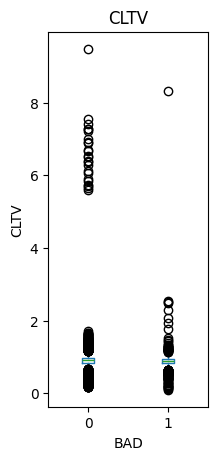

In [23]:
# Boxplotd de CLTV
fig, ax = plt.subplots(figsize=(2,5))
hmeq_prep.boxplot(column="CLTV", by="BAD", ax=ax, grid=False)
ax.set_title("CLTV")
ax.set_xlabel("BAD")
ax.set_ylabel("CLTV")
plt.suptitle("")

In [24]:
p995 = hmeq_prep["CLTV"].quantile(0.995)
hmeq_prep[hmeq_prep["CLTV"] >= p995] \
    .sort_values("CLTV", ascending=False) \
    [["BAD","LOAN","MORTDUE","VALUE","CLTV"]]

,BAD,LOAN,MORTDUE,VALUE,CLTV
3538,0,18600,57300.0,8000.0,9.487500
4225,1,22000,82000.0,12500.0,8.320000
5522,0,34100,241931.0,36486.0,7.565395
5548,0,35200,239513.0,37076.0,7.409456
5549,0,35200,234682.0,37079.0,7.278567
5434,0,32000,232000.0,36300.0,7.272727
5539,0,34900,236340.0,37598.0,7.214214
5540,0,35000,240994.0,39401.0,7.004746
5514,0,33900,232317.0,38412.0,6.930569
5459,0,32600,233216.0,38583.0,6.889459


##### 2.1.1 Tratamiento de Valores Extremos en CLTV

El análisis de la distribución de CLTV reveló la presencia de 25 registros con valores superiores a 5 con máximo de 9,49. 
Como mencionamos anteriormente, desde una perspectiva financiera, un CLTV superior a 1 implica que la deuda total del cliente supera el valor de tasación del inmueble.  

Valores en el rango 5–9.5 no tienen interpretación económica válida en el contexto de préstamos con garantía hipotecaria (HMEQ) y apuntan con alta probabilidad a errores de captura en la variable VALUE, cuyos mínimos (8.000 USD) resultan inverosímiles para inmuebles hipotecados en economías desarrolladas.

La inspección detallada de estos 25 registros confirmó adicionalmente que todos, excepto 1, corresponden a clientes sin default (BAD = 0), lo que refuerza la hipótesis de error de datos: no existe evidencia de que representen perfiles de riesgo extremo con valor predictivo real.

El boxplot segmentado por BAD confirma visualmente este diagnóstico. En ambos grupos la distribución central de CLTV se concentra por debajo de 2.55.  Los valores anómalos aparecen como
puntos aislados claramente separados del cuerpo de la distribución, con un **gap visual nítido entre 2.55 y 5.0** en el que no existe ninguna observación. Este vacío es de dificil interpretación económica y con alta probabilidad constituyen errores de captura de datos. 

##### Criterio de tratamiento
Se descarta la winsorización estadística por percentil (p99, p99.5) en favor de un **umbral económico**: cap en CLTV = 2.55.

Este umbral se justifica por tres razones:

1. **Respaldo empírico en los datos**: el boxplot muestran un gap estructural entre los 25 registros anómalos  donde CLTV > 5 y el resto de observaciones (CLTV ≤ 2.55). La ausencia de valores en el intervalo (2.55, 5.0) confirma que el corte no es arbitrario sino que refleja una discontinuidad real en los datos.

2. **Interpretación financiera**: un CLTV hasta 2.55 implica una deuda total equivalente al 250% del valor del inmueble, situación conocida como *negative equity* severa pero no imposible en escenarios de estrés donde se puede dar la depreciación del activo o reestructuración de deuda. 

3. **Alineación con estándares regulatorios**: las guías de la EBA (European Banking Authority) sobre validación de modelos IRB (Internal Ratings-Based) exigen
 documentar y justificar el tratamiento de datos anómalos. Un umbral basado en criterio económico es más transparente y auditable que un criterio puramente estadístico, cuya elección (p99 vs. p99.5) podría considerarse arbitraria.

##### Tratamiento aplicado
Los 25 registros con CLTV > 2.55 se reemplazan por el valor 2.55. No se elimina ninguna observación del dataset — se preservan las 5.960 filas originales.

|  Variable |  Descripción | 
|----------|:---------|
| Umbral de intervención | CLTV > 2.55 |
| Valor de reemplazo | 2.55 |
| Registros modificados | 25 (0.42% del dataset) |
| Observaciones eliminadas | 0 |
| Método | Cap por umbral económico |

In [25]:
CLTV_CAP = 2.55
hmeq_prep["CLTV"] = hmeq_prep["CLTV"].clip(upper=CLTV_CAP)
hmeq_prep

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,CLTV
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN,0.690839
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN,1.043173
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN,0.898204
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN,0.888393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347,1.620713
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971,1.544874
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590,1.541529
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882,1.525892


In [26]:
# Información de MORTDUE y VALUE capturada con CLTV
# Elimnar columnas originales relacionadas 
hmeq_prep = hmeq_prep.drop(columns=["MORTDUE", "VALUE"])

In [27]:
hmeq_prep.head(10)

,BAD,LOAN,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,CLTV
0,1,1100,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN,0.690839
1,1,1300,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN,1.043173
2,1,1500,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN,0.898204
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN,0.888393
5,1,1700,HomeImp,Other,9.0,0.0,0.0,101.466002,1.0,8.0,37.113614,0.799802
6,1,1800,HomeImp,Other,5.0,3.0,2.0,77.100000,1.0,17.0,NaN,0.884496
7,1,1800,HomeImp,Other,11.0,0.0,0.0,88.766030,0.0,8.0,36.884894,0.704141
8,1,2000,HomeImp,Other,3.0,0.0,2.0,216.933333,1.0,12.0,NaN,0.742405
9,1,2000,HomeImp,Sales,16.0,0.0,0.0,115.800000,0.0,13.0,NaN,NaN


### 3. Train y Test

In [28]:
# train y test split
train, test = train_test_split(hmeq_prep, test_size=0.3, random_state=123, stratify=hmeq_prep['BAD'])

In [29]:
# Número total de observaciones en train
n_train = len(train)
# Número de defaults (BAD = 1)
n_bad = train["BAD"].sum()
# Número de no-defaults (BAD = 0)
n_good = n_train - n_bad
# Tasa de default
default_rate = n_bad / n_train

print(f"Observaciones totales (train): {n_train}")
print(f"No defaults (Good): {n_good}")
print(f"Defaults (Bad): {n_bad}")
print(f"Tasa de default: {default_rate:.2%}")

Observaciones totales (train): 4172
No defaults (Good): 3340
Defaults (Bad): 832
Tasa de default: 19.94%


### 4. Information Value

In [30]:
# Calcular el poder predictivo de las variables utilizando IV para el conjunto de entrenamiento
iv = sc.iv(train,  y="BAD")

# Reducir la precisión a 2 decimales y mostrar el resultado
pd.set_option("display.float_format", "{:.4f}".format)
print(iv)

   variable  info_value
4      LOAN      0.8564
9    DELINQ      0.6610
0     DEROG      0.4463
10      YOJ      0.3639
7      CLNO      0.2577
1      NINQ      0.1685
8       JOB      0.1398
3     CLAGE      0.0687
6   DEBTINC      0.0432
2      CLTV      0.0388
5    REASON      0.0037


Recordemos que IV es:

$$
IV = \sum_{i=1}^{n} (perct_{buenos,i} - perct_{malos,i}) \times WoE_i
$$

Mide como de bueno una variable separa las dos clases de la variable BAD. Nos da una señal de que variables son buenas predictoras cuando el valor es alto entre 0.3 y 0.5 mientras que una variable por debajo de 0.02 no aporta poder de predicción como es en nuestro caso la variable REASON. 

No obstante, la variable LOAN y DELINQ aportan demasiado IV y esto activa una alerta sospechosa de posible data leakage o una (muy) alta correlación con la variable target. 

La variable LOAN serán objeto de un mayor análisis cuando discreticemos las variables. 
En cambio, la variable DELINQ representa el número de veces que el cliente ha estado en mora en los últimos 12 meses. 
Un valor alto de DELINQ indica un historial crediticio problemático, lo que se asocia con un mayor riesgo de default. Es por ello,  que IV alto en continuo y binned es consistente con la naturaleza de la variable.


### 5. Discretización de variables con optimal binning

In [31]:
# Discretización supervisada  o agrupación de las variables (binning). Aplicaremos algoritmos de optimal binning y ajuste de modelo.
def variables_analysis(train, variable, direction):
    name = variable
    aux = train.loc[:, ["BAD", name]].copy() # En una copia, seleccionamos  vble objetivo y vble a analizar

    if aux[name].dtype == np.dtype("O"): # Si name es de tipo object
        aux[name] = aux[name].astype(str) # lo convertimos a string
        
    y = aux["BAD"] # Objetivo
    X = aux[name] # Explicativa

    dtype = "numerical" if np.issubdtype(train[variable].dtype, np.number) else "categorical"


# Crear el objeto OptimalBinning y ajustar el modelo
    optb = OptimalBinning(name=name,
        monotonic_trend = direction, # puede ser "ascending" (BAD = 1 cuando variable "name" aumenta) o "descending" (BAD = 0 cuando variable "name" aumenta)
        min_bin_size=0.05, max_n_bins=6,   # al menos 5% de datos en cada bin y máximo 6 bins
        dtype=dtype) # Si la variable es numérica, numerical y si es categórica, categorical
    optb.fit(X, y) # Ajustar el modelo en train

    return(optb)

In [32]:
# Importante entender:
# El parámetro monotonic_trend se refiere a la dirección del RIESGO respecto a la variable:
# "ascending"  → a mayor valor de la variable, mayor riesgo de default (ej: DELINQ, DEROG, NINQ)
# "descending" → a mayor valor de la variable, menor riesgo de default (ej: YOJ, CLNO, CLAGE)
# None         → sin restricción de monotonicidad (ej: LOAN, LTV — relación no lineal)
# Como el WoE es inversamente proporcional al riesgo, ascending produce WoE descendente y viceversa.
bin_LOAN = variables_analysis(train, "LOAN", None) 
bin_DELINQ = variables_analysis(train, "DELINQ", "ascending")
bin_DEROG = variables_analysis(train, "DEROG", "ascending")
bin_YOJ = variables_analysis(train, "YOJ", "descending")
bin_CLNO = variables_analysis(train, "CLNO", "descending")
bin_NINQ = variables_analysis(train, "NINQ", "ascending")
bin_JOB = variables_analysis(train, "JOB", None)
bin_CLAGE = variables_analysis(train, "CLAGE", "descending")
bin_DEBTINC = variables_analysis(train, "DEBTINC", "ascending")
bin_CLTV = variables_analysis(train, "CLTV", None)  # si tiene sentido
bin_REASON = variables_analysis(train, "REASON", None) 

### 6. Visualización de bin_variables

In [33]:
# LOAN TABLE
bin_LOAN.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 6050.00)",229,0.0549,119,110,0.4803,-1.3113,0.1266,0.0148
1,"[6050.00, 10050.00)",621,0.1488,474,147,0.2367,-0.2191,0.0076,0.0010
2,"[10050.00, 13950.00)",764,0.1831,632,132,0.1728,0.1762,0.0054,0.0007
3,"[13950.00, 15050.00)",219,0.0525,152,67,0.3059,-0.5707,0.0200,0.0025
4,"[15050.00, 36450.00)",2067,0.4954,1754,313,0.1514,0.3336,0.0497,0.0062
5,"[36450.00, inf)",272,0.0652,209,63,0.2316,-0.1907,0.0025,0.0003
6,Special,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
7,Missing,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
Totals,,4172,1.0000,3340,832,0.1994,,0.2118,0.0254


'''Un matiz importante es el IV de LOAN. Mientras que en la variable continua IV era 0.82, ahora es 0.212. 
Esto se debe a que al discretizar la variable, se pierde parte de la información original.
Esto es positivo con los valores obtenidos ya que se reduce el ruido y evita sobreajuste mientras que el poder predictivo se mantiene.
Por lo tanto, El IV alto en continuo era ruido estadístico amplificado por la granularidad, no una señal de leakage '''


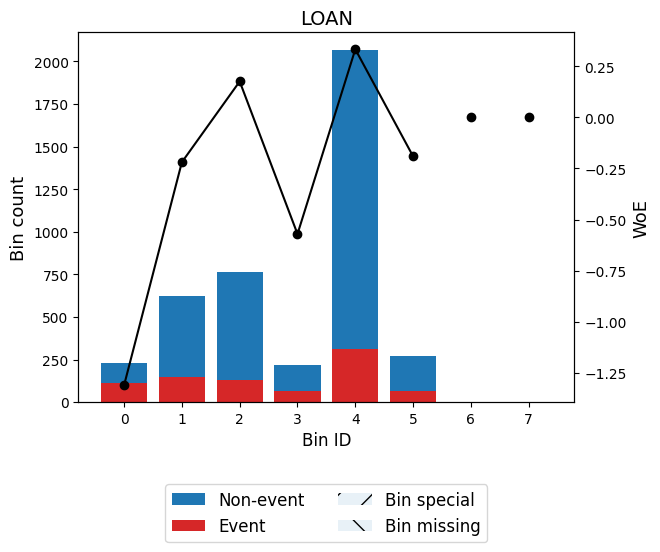

In [34]:
# LOAN PLOT
bin_LOAN.binning_table.plot('woe')
# La relación no es monótona pero si es importante el alto nivel de default en el primer bin. Es decir, hay mayor riesgo en préstamos pequeños. 

In [35]:
# DELINQ TABLE
bin_DELINQ.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",2905,0.6963,2507,398,0.1370,0.4505,0.1226,0.0152
1,"[0.50, 2.50)",639,0.1532,407,232,0.3631,-0.8278,0.1300,0.0158
2,"[2.50, inf)",224,0.0537,76,148,0.6607,-2.0564,0.3190,0.0341
3,Special,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
4,Missing,404,0.0968,350,54,0.1337,0.4791,0.0191,0.0024
Totals,,4172,1.0000,3340,832,0.1994,,0.5907,0.0674


En este caso. El IV de DELINQ es alto tanto en continuo (0.63) como en binned (0.56). No obstante, comprender la variable es necesario. 
DELINQ representa el número de veces que el cliente ha estado en mora en los últimos 12 meses. 
Un valor alto de DELINQ indica un historial crediticio problemático, lo que se asocia con un mayor riesgo de default. Es por ello, 
que IV alto en continuo y binned es consistente con la naturaleza de la variable.

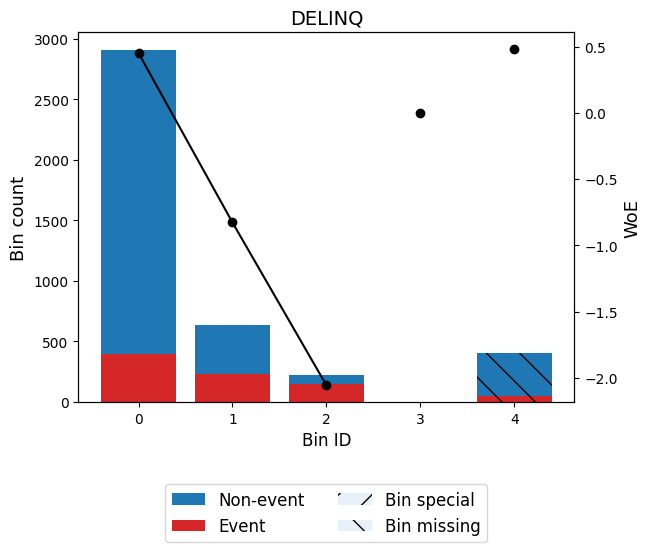

In [36]:
# DELINQ PLOT
bin_DELINQ.binning_table.plot("woe")

In [37]:
bin_DEROG.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",3177,0.7615,2655,522,0.1643,0.2366,0.0396,0.0049
1,"[0.50, inf)",497,0.1191,252,245,0.4930,-1.3617,0.2982,0.0346
2,Special,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
3,Missing,498,0.1194,433,65,0.1305,0.5065,0.0261,0.0032
Totals,,4172,1.0000,3340,832,0.1994,,0.3640,0.0428


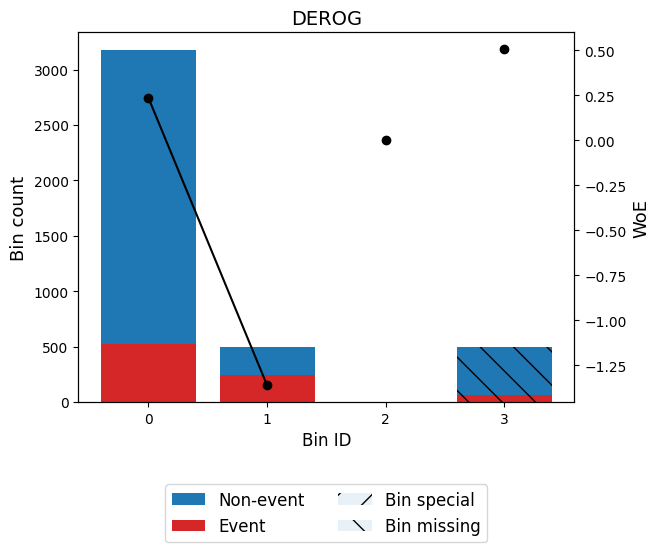

In [38]:
bin_DEROG.binning_table.plot("woe")

In [39]:
bin_YOJ.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 3.95)",1104,0.2646,819,285,0.2582,-0.3343,0.0325,0.0040
1,"[3.95, 5.75)",471,0.1129,361,110,0.2335,-0.2015,0.0049,0.0006
2,"[5.75, 15.50)",1509,0.3617,1227,282,0.1869,0.0805,0.0023,0.0003
3,"[15.50, 22.40)",432,0.1035,354,78,0.1806,0.1227,0.0015,0.0002
4,"[22.40, inf)",301,0.0721,267,34,0.1130,0.6710,0.0262,0.0032
5,Special,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
6,Missing,355,0.0851,312,43,0.1211,0.5919,0.0247,0.0030
Totals,,4172,1.0000,3340,832,0.1994,,0.0921,0.0114


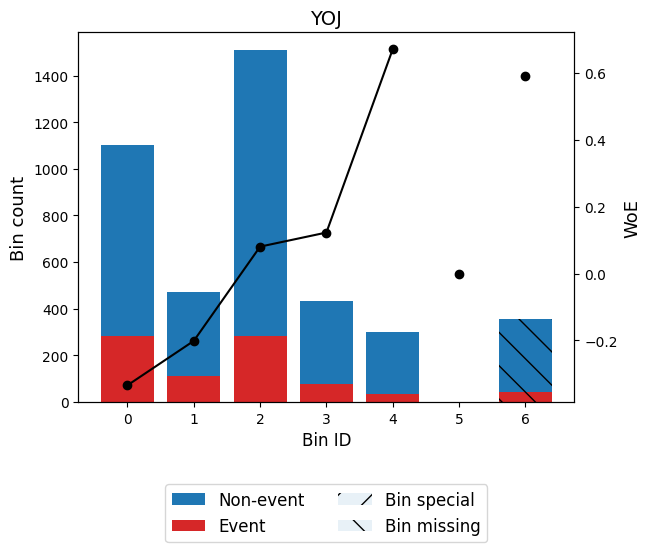

In [40]:
bin_YOJ.binning_table.plot("woe")

In [41]:
bin_CLNO.binning_table.build()


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 9.50)",377,0.0904,258,119,0.3156,-0.6161,0.0405,0.0050
1,"[9.50, inf)",3628,0.8696,2955,673,0.1855,0.0896,0.0068,0.0008
2,Special,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
3,Missing,167,0.0400,127,40,0.2395,-0.2346,0.0024,0.0003
Totals,,4172,1.0000,3340,832,0.1994,,0.0497,0.0061


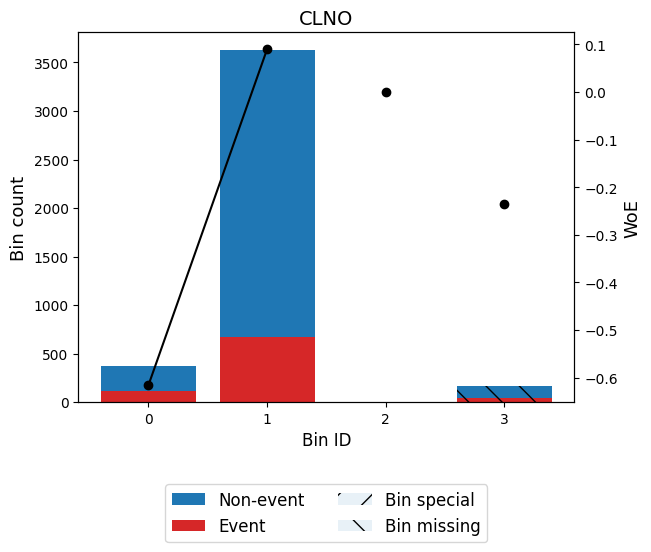

In [42]:
bin_CLNO.binning_table.plot("woe")


In [43]:
bin_NINQ.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",1749,0.4192,1479,270,0.1544,0.3108,0.0368,0.0046
1,"[0.50, 1.50)",943,0.2260,762,181,0.1919,0.0476,0.0005,0.0001
2,"[1.50, 2.50)",538,0.1290,409,129,0.2398,-0.2360,0.0077,0.0010
3,"[2.50, 3.50)",287,0.0688,212,75,0.2613,-0.3508,0.0094,0.0012
4,"[3.50, inf)",288,0.0690,168,120,0.4167,-1.0534,0.0989,0.0118
5,Special,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
6,Missing,367,0.0880,310,57,0.1553,0.3036,0.0074,0.0009
Totals,,4172,1.0000,3340,832,0.1994,,0.1606,0.0195


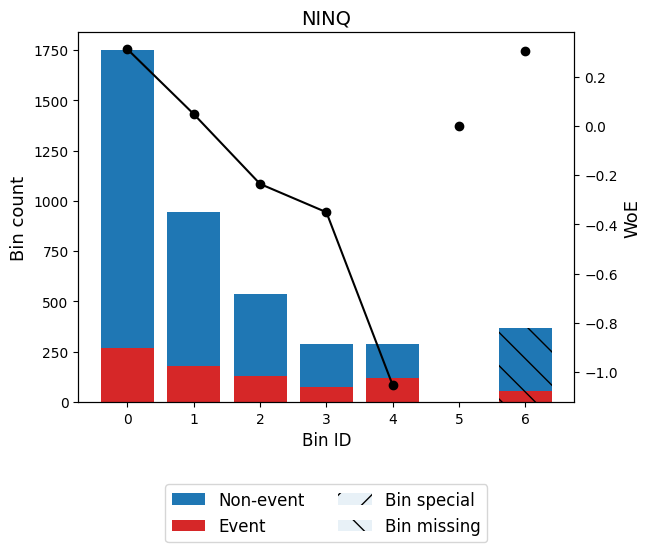

In [44]:
bin_NINQ.binning_table.plot("woe")

In [45]:
bin_JOB.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"[nan, Office]",882,0.2114,775,107,0.1213,0.5901,0.0610,0.0075
1,[ProfExe],897,0.2150,750,147,0.1639,0.2397,0.0115,0.0014
2,[Other],1663,0.3986,1279,384,0.2309,-0.1867,0.0147,0.0018
3,[Mgr],514,0.1232,393,121,0.2354,-0.2119,0.0059,0.0007
4,"[Self, Sales]",216,0.0518,143,73,0.3380,-0.7175,0.0322,0.0039
5,Special,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
6,Missing,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
Totals,,4172,1.0000,3340,832,0.1994,,0.1253,0.0155


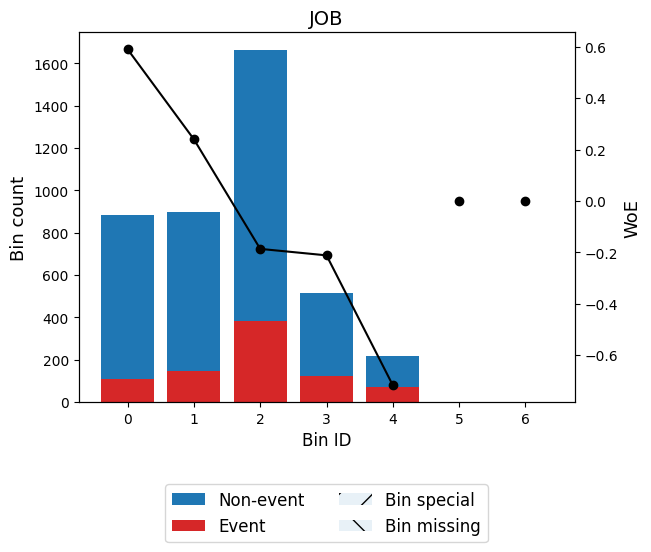

In [46]:
bin_JOB.binning_table.plot("woe")

In [47]:
bin_CLAGE.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 75.91)",266,0.0638,169,97,0.3647,-0.8347,0.0551,0.0067
1,"[75.91, 92.78)",271,0.0650,193,78,0.2878,-0.4839,0.0174,0.0022
2,"[92.78, 154.28)",1145,0.2744,854,291,0.2541,-0.3133,0.0295,0.0037
3,"[154.28, 173.54)",266,0.0638,211,55,0.2068,-0.0454,0.0001,0.0000
4,"[173.54, 238.96)",1091,0.2615,931,160,0.1467,0.3712,0.0321,0.0040
5,"[238.96, inf)",912,0.2186,816,96,0.1053,0.7502,0.0967,0.0118
6,Special,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
7,Missing,221,0.0530,166,55,0.2489,-0.2852,0.0047,0.0006
Totals,,4172,1.0000,3340,832,0.1994,,0.2356,0.0289


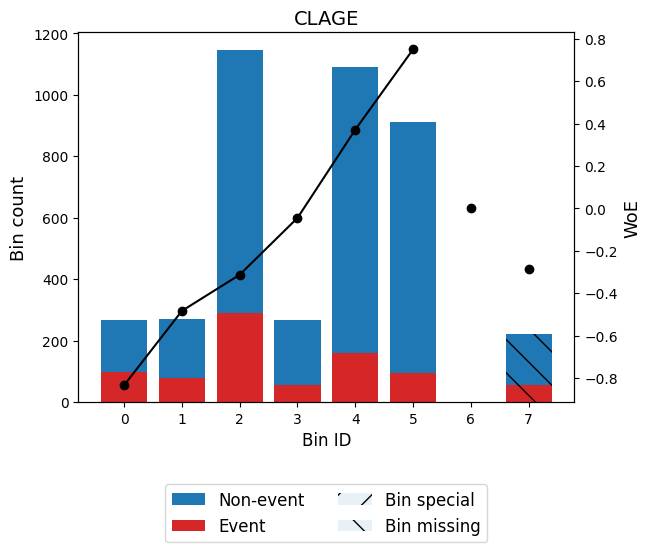

In [48]:
bin_CLAGE.binning_table.plot("woe")

In [49]:
bin_DEBTINC.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 31.21)",1091,0.2615,1034,57,0.0522,1.5082,0.3636,0.0416
1,"[31.21, 34.48)",469,0.1124,444,25,0.0533,1.4871,0.1530,0.0175
2,"[34.48, 40.21)",1165,0.2792,1077,88,0.0755,1.1147,0.2415,0.0287
3,"[40.21, 42.34)",366,0.0877,334,32,0.0874,0.9555,0.0588,0.0071
4,"[42.34, inf)",209,0.0501,128,81,0.3876,-0.9323,0.0550,0.0066
5,Special,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
6,Missing,872,0.2090,323,549,0.6296,-1.9203,1.0814,0.1176
Totals,,4172,1.0000,3340,832,0.1994,,1.9534,0.2192


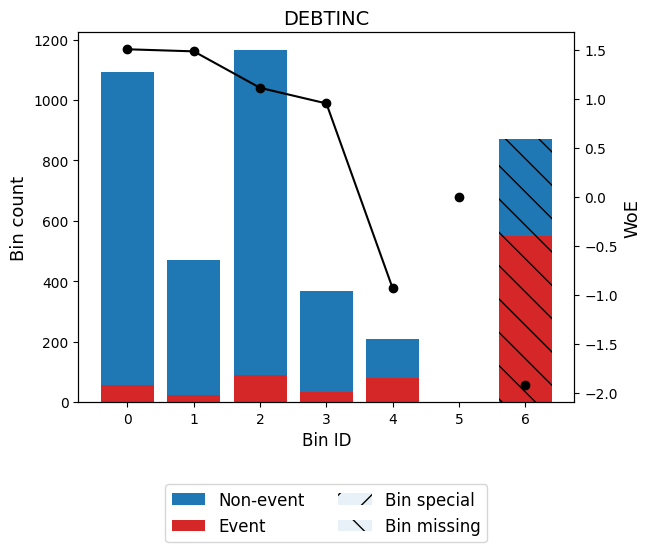

In [50]:
bin_DEBTINC.binning_table.plot("woe")

In [51]:
bin_CLTV.binning_table.build()


,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.70)",346,0.0829,258,88,0.2543,-0.3143,0.0090,0.0011
1,"[0.70, 0.89)",1278,0.3063,1045,233,0.1823,0.1108,0.0036,0.0005
2,"[0.89, 0.90)",221,0.0530,146,75,0.3394,-0.7238,0.0336,0.0041
3,"[0.90, 0.93)",475,0.1139,424,51,0.1074,0.7280,0.0478,0.0058
4,"[0.93, 0.95)",353,0.0846,258,95,0.2691,-0.3908,0.0144,0.0018
5,"[0.95, inf)",1083,0.2596,924,159,0.1468,0.3699,0.0316,0.0039
6,Special,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
7,Missing,416,0.0997,285,131,0.3149,-0.6126,0.0442,0.0054
Totals,,4172,1.0000,3340,832,0.1994,,0.1843,0.0227


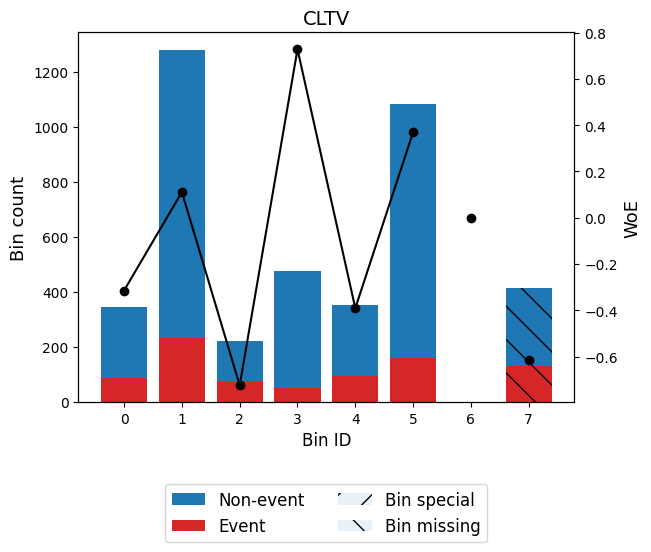

In [52]:
bin_CLTV.binning_table.plot("woe")

In [53]:
bin_REASON.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"[nan, DebtCon]",2937,0.7040,2370,567,0.1931,0.0404,0.0011,0.0001
1,[HomeImp],1235,0.2960,970,265,0.2146,-0.0923,0.0026,0.0003
2,Special,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
3,Missing,0,0.0000,0,0,0.0000,0.0000,0.0000,0.0000
Totals,,4172,1.0000,3340,832,0.1994,,0.0037,0.0005


**REASON**: Tiene un IV de 0.0037 mientras que el umbral de descarte habitual: 0.02. Se incluye de forma preliminar para validar su significancia mediante el p-value del GLM. Si p-value > 0.05, se retira por no aportar capacidad discriminatoria.

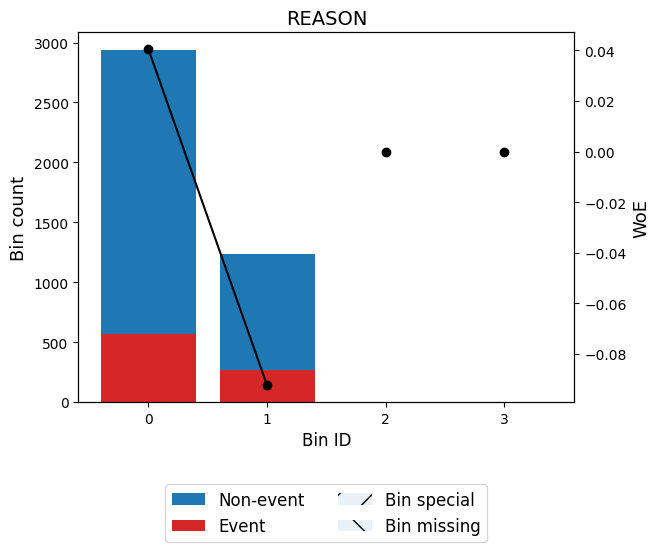

In [54]:
bin_REASON.binning_table.plot("woe")

### 7. Preparación de datos para regresión

In [55]:
# transformacion de numéricas a categóricas con los bins obtenidos
train["woe_LOAN"] = bin_LOAN.transform(train["LOAN"], metric="woe")
train["woe_DELINQ"] = bin_DELINQ.transform(train["DELINQ"], metric="woe")
train["woe_DEROG"] = bin_DEROG.transform(train["DEROG"], metric="woe")
train["woe_YOJ"] = bin_YOJ.transform(train["YOJ"], metric="woe")
train["woe_CLNO"] = bin_CLNO.transform(train["CLNO"], metric="woe")
train["woe_NINQ"] = bin_NINQ.transform(train["NINQ"], metric="woe")
train["woe_JOB"] = bin_JOB.transform(train["JOB"], metric="woe")
train["woe_CLAGE"] = bin_CLAGE.transform(train["CLAGE"], metric="woe")
train["woe_DEBTINC"] = bin_DEBTINC.transform(train["DEBTINC"], metric="woe")
train["woe_CLTV"] = bin_CLTV.transform(train["CLTV"], metric="woe")
train["woe_REASON"] = bin_REASON.transform(train["REASON"], metric="woe")

In [56]:
train.columns

Index(['BAD', 'LOAN', 'REASON', 'JOB', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE',
       'NINQ', 'CLNO', 'DEBTINC', 'CLTV', 'woe_LOAN', 'woe_DELINQ',
       'woe_DEROG', 'woe_YOJ', 'woe_CLNO', 'woe_NINQ', 'woe_JOB', 'woe_CLAGE',
       'woe_DEBTINC', 'woe_CLTV', 'woe_REASON'],
      dtype='object')

In [57]:
#comprobar que no hay NA en las variables transformadas
train[[c for c in train.columns if c.startswith("woe_")]].isna().sum()

woe_LOAN       0
woe_DELINQ     0
woe_DEROG      0
woe_YOJ        0
woe_CLNO       0
woe_NINQ       0
woe_JOB        0
woe_CLAGE      0
woe_DEBTINC    0
woe_CLTV       0
woe_REASON     0
dtype: int64

In [58]:
test["woe_LOAN"] = bin_LOAN.transform(test["LOAN"], metric="woe")
test["woe_DELINQ"] = bin_DELINQ.transform(test["DELINQ"], metric="woe")
test["woe_DEROG"] = bin_DEROG.transform(test["DEROG"], metric="woe")
test["woe_YOJ"] = bin_YOJ.transform(test["YOJ"], metric="woe")
test["woe_CLNO"] = bin_CLNO.transform(test["CLNO"], metric="woe")
test["woe_NINQ"] = bin_NINQ.transform(test["NINQ"], metric="woe")
test["woe_JOB"] = bin_JOB.transform(test["JOB"], metric="woe")
test["woe_CLAGE"]  = bin_CLAGE.transform(test["CLAGE"],  metric="woe")
test["woe_DEBTINC"]  = bin_DEBTINC.transform(test["DEBTINC"], metric="woe")
test["woe_CLTV"]  = bin_CLTV.transform(test["CLTV"], metric="woe")
test["woe_REASON"]  = bin_REASON.transform(test["REASON"], metric="woe")

In [59]:
test.columns

Index(['BAD', 'LOAN', 'REASON', 'JOB', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE',
       'NINQ', 'CLNO', 'DEBTINC', 'CLTV', 'woe_LOAN', 'woe_DELINQ',
       'woe_DEROG', 'woe_YOJ', 'woe_CLNO', 'woe_NINQ', 'woe_JOB', 'woe_CLAGE',
       'woe_DEBTINC', 'woe_CLTV', 'woe_REASON'],
      dtype='object')

In [60]:
# correlacion
variables_woe = [
    "woe_LOAN",
    "woe_DELINQ",
    "woe_DEROG",
    "woe_YOJ",
    "woe_CLNO",
    "woe_NINQ",
    "woe_JOB",
    "woe_CLAGE",
    "woe_DEBTINC",
    "woe_CLTV",
    # "woe_REASON" # Tras correr el modelo, la variable no aporta información relevante.
]

correlations = train[variables_woe].corr().round(4)
correlations

,woe_LOAN,woe_DELINQ,woe_DEROG,woe_YOJ,woe_CLNO,woe_NINQ,woe_JOB,woe_CLAGE,woe_DEBTINC,woe_CLTV
woe_LOAN,1.0000,0.0748,0.0176,0.0536,0.1066,-0.0119,0.0309,0.0879,0.1582,0.0677
woe_DELINQ,0.0748,1.0000,0.2264,-0.0013,-0.0670,0.0735,0.0097,0.0134,0.1856,0.0799
woe_DEROG,0.0176,0.2264,1.0000,0.0459,-0.0009,0.1717,0.0784,0.0699,0.1517,0.0428
woe_YOJ,0.0536,-0.0013,0.0459,1.0000,0.1006,0.0497,0.0049,0.1634,0.0668,-0.0036
woe_CLNO,0.1066,-0.0670,-0.0009,0.1006,1.0000,-0.0426,0.0946,0.1929,-0.0212,0.0397
woe_NINQ,-0.0119,0.0735,0.1717,0.0497,-0.0426,1.0000,0.0763,0.0821,0.1840,-0.0184
woe_JOB,0.0309,0.0097,0.0784,0.0049,0.0946,0.0763,1.0000,0.0571,0.0530,0.0211
woe_CLAGE,0.0879,0.0134,0.0699,0.1634,0.1929,0.0821,0.0571,1.0000,0.0556,-0.0396
woe_DEBTINC,0.1582,0.1856,0.1517,0.0668,-0.0212,0.1840,0.0530,0.0556,1.0000,0.1369
woe_CLTV,0.0677,0.0799,0.0428,-0.0036,0.0397,-0.0184,0.0211,-0.0396,0.1369,1.0000


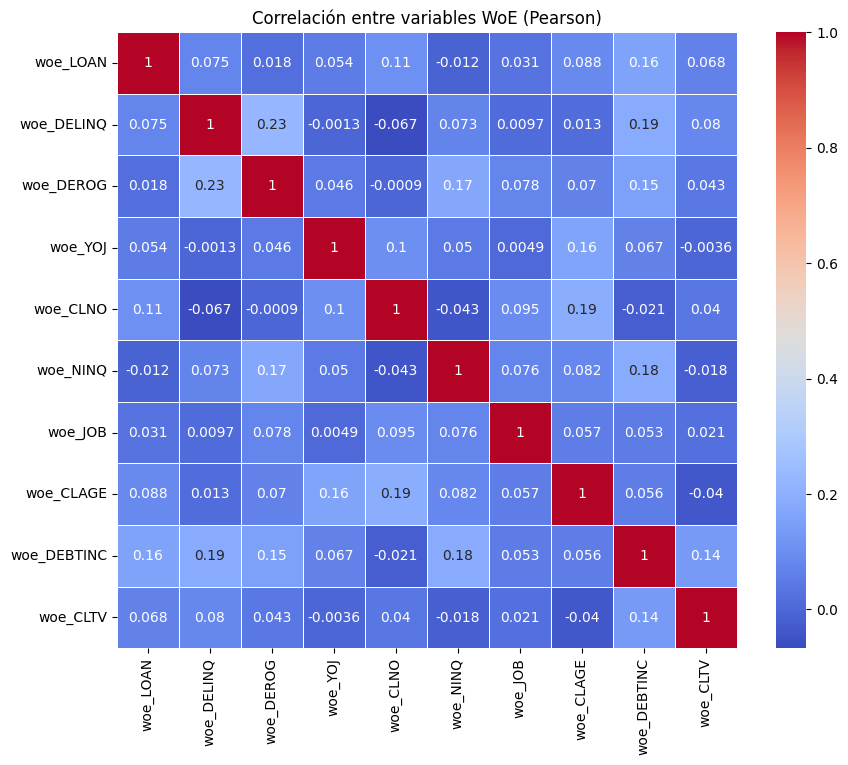

In [61]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, 
            annot=True, 
            cmap="coolwarm", 
            linewidths=0.5)

plt.title("Correlación entre variables WoE (Pearson)")
plt.show()

# No hay multicolinealidad relevante y no es necesario eliminar ninguna por correlación.

In [62]:
# las variables relevantes para el modelo serán las transformadas con WoE
formula = "BAD ~ " + " + ".join(variables_woe)
formula

'BAD ~ woe_LOAN + woe_DELINQ + woe_DEROG + woe_YOJ + woe_CLNO + woe_NINQ + woe_JOB + woe_CLAGE + woe_DEBTINC + woe_CLTV'

### 8. Modelo Logístico con Variables en WoE

El modelo estimado es un **GLM binomial con función de enlace logit**, cuya forma funcional es:

$$
\log\left(\frac{PD}{1 - PD}\right) 
= \beta_0 
+ \beta_1 \cdot WoE_1 
+ \beta_2 \cdot WoE_2 
+ \dots 
+ \beta_k \cdot WoE_k
$$

Donde:

- \( PD \) es la **Probabilidad de Incumplimiento (Probability of Default)**.
- \( \frac{PD}{1-PD} \) representa los **odds de default**.
- \( \log\left(\frac{PD}{1-PD}\right) \) es el **log-odds**.
- \( \beta_0 \) es el intercepto.
- \( \beta_i \) es el coeficiente asociado a cada variable transformada en **Weight of Evidence (WoE)**.

Despejando la probabilidad:

$$
PD = \frac{1}{1 + e^{-\left(\beta_0 + \sum_{i=1}^{k} \beta_i \cdot WoE_i\right)}}
$$

In [63]:
# Estimación del modelo de regresión logística con statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.glm(
    formula=formula,
    data=train,
    family=sm.families.Binomial(link=sm.families.links.logit())
).fit()

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    BAD   No. Observations:                 4172
Model:                            GLM   Df Residuals:                     4161
Model Family:                Binomial   Df Model:                           10
Link Function:                  logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1275.7
Date:               ma., 26 may. 2026   Deviance:                       2551.3
Time:                        08:20:33   Pearson chi2:                 4.24e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.3214
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -0.3848      0.064     -6.014      

#### Resultados del GLM

Todas las variables resultan significativas (p-value < 0.005) **excepto `woe_REASON`** (p-value = 0.570, coef = +0.51), que se retira por tres motivos: Bajo IV, no es significativa estadísticamente e inversión del signo respecto al resto del modelo.

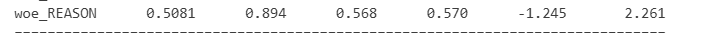

**Sobre el signo de los coeficientes**: en un GLM con WoE construidas por `optbinning` (fórmula `ln(%no_event / %event)`), un WoE alto identifica bins de **bajo riesgo**. Por tanto, los coeficientes deben salir **negativos** es la convención inversa a un modelo con variables normales, donde `DEBTINC` aumenta el log-odds de default y produce coeficiente positivo. La variable más fuerte es `woe_DEBTINC` (coef = -1.59); Pseudo R² = 0.32.

### 9. Evaluación

In [64]:
pr_train = model.predict(train)
pr_test  = model.predict(test)

auc_train = roc_auc_score(train["BAD"], pr_train)
auc_test  = roc_auc_score(test["BAD"], pr_test)

gini_train = 2 * auc_train - 1
gini_test  = 2 * auc_test - 1

print("AUC Train:", round(auc_train,4))
print("AUC Test :", round(auc_test,4))
print("Gini Train:", round(gini_train,4))
print("Gini Test :", round(gini_test,4))

AUC Train: 0.8927
AUC Test : 0.8935
Gini Train: 0.7853
Gini Test : 0.787


En esta fase se ha estimado un modelo de Regresión Logística utilizando como variables explicativas las variables previamente transformadas mediante Weight of Evidence (WoE).
El flujo metodológico seguido ha sido:

- División de la muestra en entrenamiento y validación (70/30 estratificado).
- Binning óptimo de cada variable en la muestra de entrenamiento.
- Transformación de cada variable a su correspondiente WoE.
- Verificación de ausencia de correlaciones relevantes.
- Estimación de un modelo GLM binomial con las variables WoE.
- Evaluación de la capacidad discriminatoria mediante AUC y Gini.

Este enfoque replica la metodología clásica de construcción de scorecards bancarios interpretables, los cuales serán mostrados más adelante.
Pseudo R-squ. (CS):0.3062 indica una capacidad explicativa elevada para un modelo binario retail

Sin overfitting: AUC Train (0.8927) ≈ AUC Test (0.8935). De hecho, AUC Test es ligeramente mayor — patrón saludable, indica que el modelo generaliza bien.  
Gini > 0.78 en test — excelente para un modelo de PD interpretable (referencia EBA: Gini > 0.40 se considera "modelo discriminativo aceptable" en IRB).  
La eliminación de REASON ha sido el filtro correcto: si la hubiéramos dejado, habríamos arrastrado ruido que perjudicaría la calibración out-of-time.  

#### Persistencia de artefactos

In [65]:
# Persistencia de artefactos — consumidos por el notebook 05 de comparación
import joblib  
from pathlib import Path       

# Carpeta models/ en la RAÍZ del proyecto (subir un nivel desde notebooks/)
models_dir = Path("../models")    # ".." = un nivel por encima del CWD actual
models_dir.mkdir(exist_ok=True)   # Crea la carpeta si no existe, sin fallar si ya está

# 1) Modelo GLM logit (statsmodels) entrenado sobre train
joblib.dump(model, models_dir / "woe_logreg_model.pkl")

# 2) Los 9 OptimalBinning que transforman cada variable cruda a WoE
#    Se agrupan en un dict para cargarlos de una sola vez en el notebook 05
bins_dict = {
    "LOAN": bin_LOAN,
    "DELINQ": bin_DELINQ,
    "DEROG": bin_DEROG,
    "YOJ": bin_YOJ,
    "CLNO": bin_CLNO,
    "NINQ": bin_NINQ,
    "JOB": bin_JOB,
    "CLAGE": bin_CLAGE,
    "DEBTINC": bin_DEBTINC,
    "CLTV": bin_CLTV,
}
joblib.dump(bins_dict, models_dir / "woe_bins.pkl")

# 3) DataFrame test — contiene BAD, variables crudas y columnas woe_*
test.to_pickle(models_dir / "woe_test_set.pkl")

# 4) DataFrame train — contiene BAD, variables crudas y columnas woe_*
train.to_pickle(models_dir / "woe_train_set.pkl")